# Breast Cancer Classification using SVM (Support Vector Machine)

In this notebook, we will classify breast cancer tumors as **Malignant (0)** or **Benign (1)** using the **Support Vector Machine (SVM)** algorithm.

We will experiment with **all four kernel tricks** offered by `sklearn`:
1. **Linear Kernel** &mdash; best when data is linearly separable.
2. **Polynomial Kernel** &mdash; captures interactions of features up to a given degree.
3. **RBF (Radial Basis Function / Gaussian) Kernel** &mdash; the most popular kernel for non-linear data.
4. **Sigmoid Kernel** &mdash; behaves like a neural network's activation function.

## Dataset
The **Breast Cancer Wisconsin (Diagnostic) Dataset** contains 569 samples with 30 numerical features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.

- **Target = 0** &rarr; Malignant (cancerous)
- **Target = 1** &rarr; Benign (non-cancerous)

## 1. Import Required Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC #Support Vector Classifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix)

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load the Dataset

In [6]:
df = pd.read_csv(r'/home/chris/Documents/Broadway Python/Lesson 1/Machine Learning/SVM/breast_cancer_dataset.csv')
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Descriptive Data Analysis 

Before applying any model, we need to understand the data: its size, types, distribution, and quality.

In [7]:
df.shape

(569, 31)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [9]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


### 3.1 Check for Missing Values

In [10]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

### 3.2 Target Class Distribution

Checking class balance is important. If one class dominates, accuracy alone can be misleading.

In [11]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

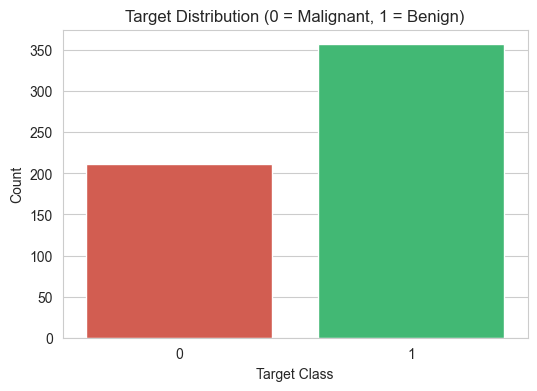

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Target Distribution (0 = Malignant, 1 = Benign)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.show()

### 3.3 Feature Correlation Heatmap

Highly correlated features can be redundant. Let's visualize the correlation matrix.

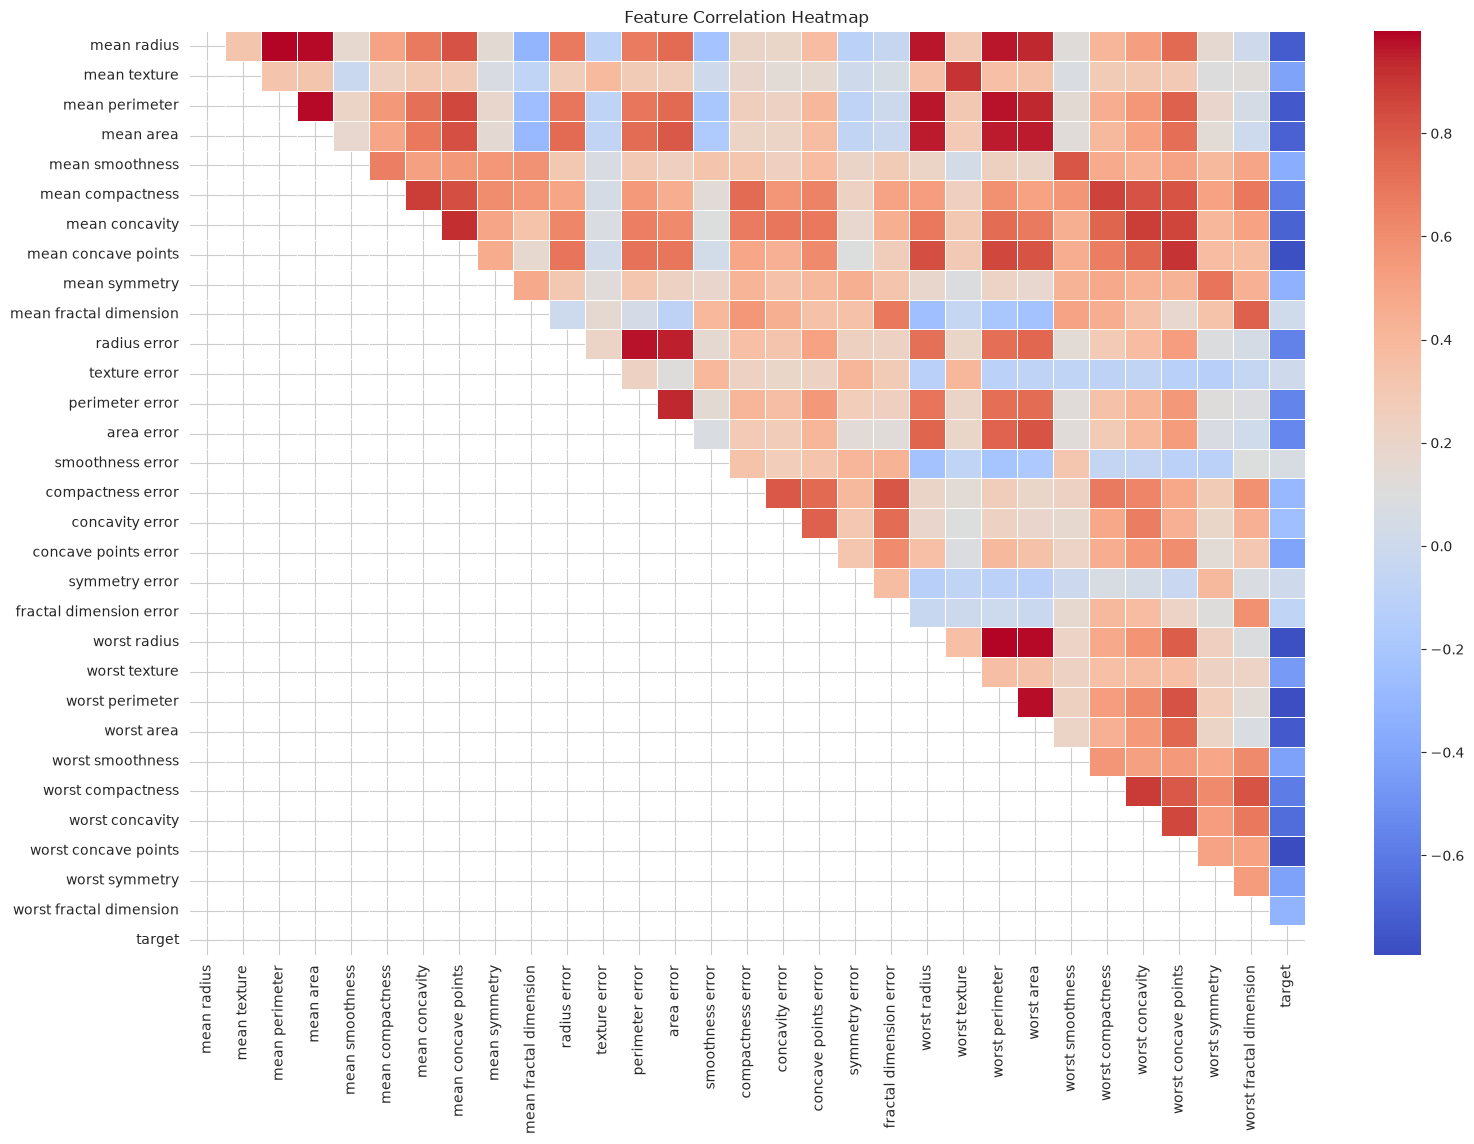

In [14]:
corr = df.corr()
mask = np.tril(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(18, 12))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

### 3.4 Removing Highly Correlated Features (Multicollinearity)

The heatmap above shows several pairs of features that are **very strongly correlated** (e.g. `mean radius`, `mean perimeter`, `mean area`, `worst radius` &mdash; all describing almost the same thing).

**Why is multicollinearity a problem?**
- It makes the model **unstable** and harder to interpret.
- It can hurt SVM performance because redundant features add noise without adding new information.
- Reduces dimensionality &rarr; **faster training** and **better generalization**.

**Strategy:** For every pair of features whose **absolute correlation is greater than 0.90**, we drop one of them.

In [15]:
target_col = "target"

# Calculate absolute correlation matrix for feature columns only
corr_matrix = df.drop(columns=[target_col]).corr().abs()

columns_to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.90:
            columns_to_drop.append(corr_matrix.columns[i])

print(f"Number of features to drop: {len(columns_to_drop)}")
print("Features being removed:")

for col in columns_to_drop:
    print(f"  - {col}")

Number of features to drop: 21
Features being removed:
  - mean perimeter
  - mean area
  - mean area
  - mean concave points
  - perimeter error
  - area error
  - area error
  - worst radius
  - worst radius
  - worst radius
  - worst texture
  - worst perimeter
  - worst perimeter
  - worst perimeter
  - worst perimeter
  - worst area
  - worst area
  - worst area
  - worst area
  - worst area
  - worst concave points


In [16]:
df_reduced = df.drop(columns=columns_to_drop)
print('Shape before:', df.shape)
print('Shape after :', df_reduced.shape)
df_reduced.head()

Shape before: (569, 31)
Shape after : (569, 21)


,mean radius,mean texture,mean smoothness,mean compactness,mean concavity,mean symmetry,mean fractal dimension,radius error,texture error,smoothness error,...,concavity error,concave points error,symmetry error,fractal dimension error,worst smoothness,worst compactness,worst concavity,worst symmetry,worst fractal dimension,target
0,17.99,10.38,0.11840,0.27760,0.3001,0.2419,0.07871,1.0950,0.9053,0.006399,...,0.05373,0.01587,0.03003,0.006193,0.1622,0.6656,0.7119,0.4601,0.11890,0
1,20.57,17.77,0.08474,0.07864,0.0869,0.1812,0.05667,0.5435,0.7339,0.005225,...,0.01860,0.01340,0.01389,0.003532,0.1238,0.1866,0.2416,0.2750,0.08902,0
2,19.69,21.25,0.10960,0.15990,0.1974,0.2069,0.05999,0.7456,0.7869,0.006150,...,0.03832,0.02058,0.02250,0.004571,0.1444,0.4245,0.4504,0.3613,0.08758,0
3,11.42,20.38,0.14250,0.28390,0.2414,0.2597,0.09744,0.4956,1.1560,0.009110,...,0.05661,0.01867,0.05963,0.009208,0.2098,0.8663,0.6869,0.6638,0.17300,0
4,20.29,14.34,0.10030,0.13280,0.1980,0.1809,0.05883,0.7572,0.7813,0.011490,...,0.05688,0.01885,0.01756,0.005115,0.1374,0.2050,0.4000,0.2364,0.07678,0


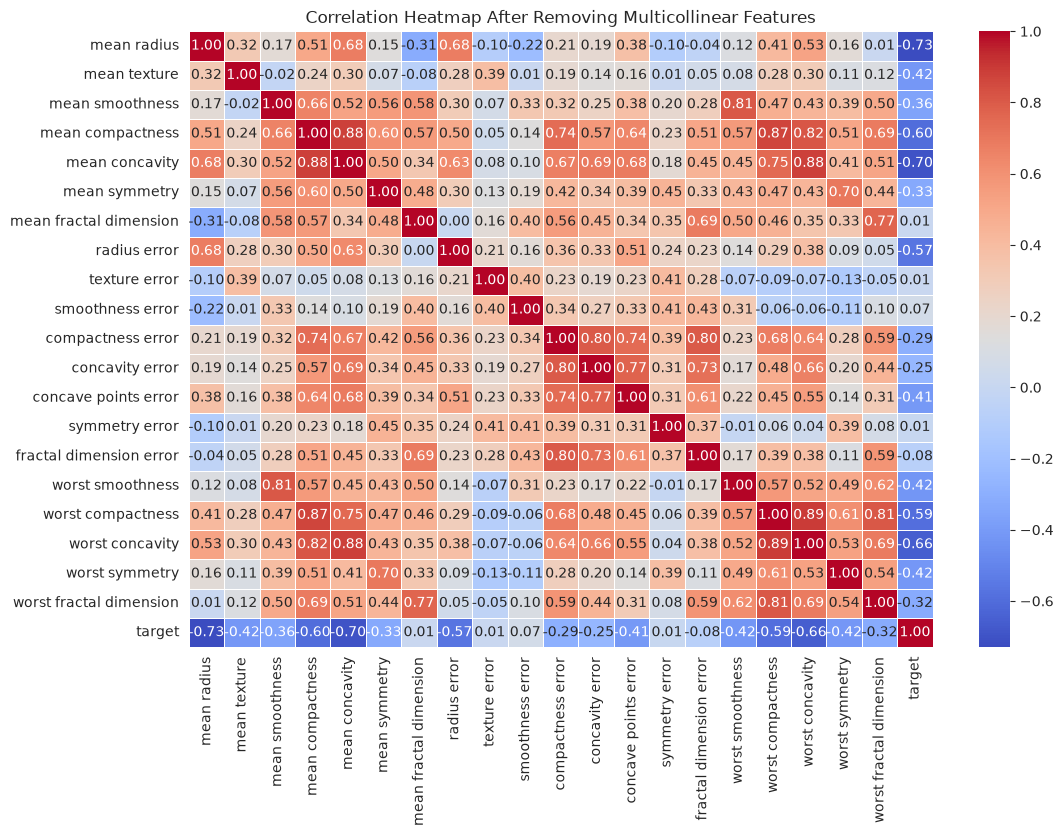

In [17]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_reduced.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap After Removing Multicollinear Features')
plt.show()

## 4. Data Preprocessing

### 4.1 Split Features (X) and Target (y)

In [18]:
X = df_reduced.drop('target', axis=1)
y = df_reduced['target']
print('Features shape:', X.shape)
print('Target shape :', y.shape)

Features shape: (569, 20)
Target shape : (569,)


### 4.2 Train-Test Split

We split the data into 80% training and 20% testing. `stratify=y` ensures class proportions are preserved in both sets.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('y_train:', y_train.shape, '| y_test:', y_test.shape)

X_train: (455, 20) | X_test: (114, 20)
y_train: (455,) | y_test: (114,)


### 4.3 Feature Scaling (Very Important for SVM!)

SVM is a **distance-based algorithm**. Features with larger magnitudes (e.g. `mean area` ranging in thousands) will dominate over smaller features (e.g. `mean smoothness` ~ 0.1) if we don't scale them.

We use **StandardScaler** which transforms each feature to have mean = 0 and standard deviation = 1.

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Mean of scaled training data (~0):', np.round(X_train_scaled.mean(), 4))
print('Std  of scaled training data (~1):', np.round(X_train_scaled.std(), 4))

Mean of scaled training data (~0): 0.0
Std  of scaled training data (~1): 1.0


## 5. SVM with All Kernel Tricks

The **kernel trick** allows SVM to operate in a higher dimensional space without actually computing the transformation explicitly. We'll train an SVM with each of the four kernels and compare their performance.

We will define a helper function to keep the code DRY.

In [21]:
def train_and_evaluate(kernel_name, **kwargs):
    """Train an SVM with the given kernel and print the evaluation report."""
    
    model = SVC(kernel=kernel_name, random_state=42, **kwargs)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    
    print(f"=== SVM with '{kernel_name}' kernel ===")
    print(f"Accuracy : {acc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    
    plt.title(f"Confusion Matrix - {kernel_name.upper()} Kernel")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return model, acc

### 5.1 Linear Kernel

$$ K(x_i, x_j) = x_i \cdot x_j $$

The linear kernel is the simplest. It performs well when the data is (almost) linearly separable &mdash; which is often the case for breast cancer data.

=== SVM with 'linear' kernel ===
Accuracy : 0.9825

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



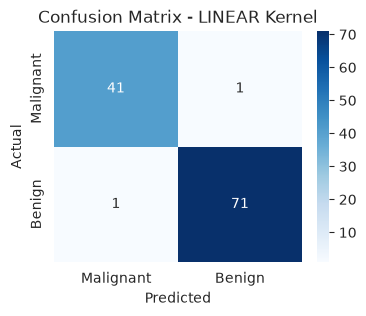

In [22]:
model_linear, acc_linear = train_and_evaluate('linear')

### 5.2 Polynomial Kernel

$$ K(x_i, x_j) = (\gamma \, x_i \cdot x_j + r)^d $$

The polynomial kernel captures feature interactions up to degree `d`. Here we use `degree=3` (default).

=== SVM with 'poly' kernel ===
Accuracy : 0.8860

Classification Report:
              precision    recall  f1-score   support

   Malignant       1.00      0.69      0.82        42
      Benign       0.85      1.00      0.92        72

    accuracy                           0.89       114
   macro avg       0.92      0.85      0.87       114
weighted avg       0.90      0.89      0.88       114



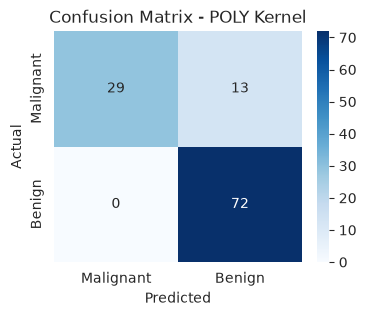

In [23]:
model_poly, acc_poly = train_and_evaluate('poly', degree=3, gamma='scale')

### 5.3 RBF (Gaussian) Kernel

$$ K(x_i, x_j) = \exp(-\gamma \, \| x_i - x_j \|^2) $$

RBF is the **most widely used kernel**. It can handle non-linear relationships very effectively and is the default in `sklearn`.

=== SVM with 'rbf' kernel ===
Accuracy : 0.9649

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.93      0.98      0.95        42
      Benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



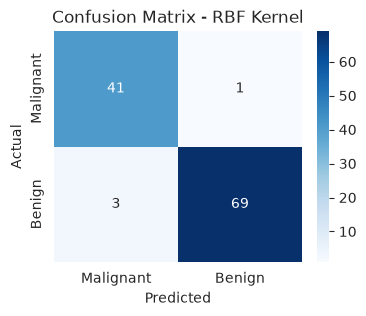

In [24]:
model_rbf, acc_rbf = train_and_evaluate('rbf', gamma='scale')

### 5.4 Sigmoid Kernel

$$ K(x_i, x_j) = \tanh(\gamma \, x_i \cdot x_j + r) $$

The sigmoid kernel behaves similarly to a neural network's activation function. It usually performs worse than RBF for most datasets but is worth trying.

=== SVM with 'sigmoid' kernel ===
Accuracy : 0.8509

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.76      0.88      0.81        42
      Benign       0.92      0.83      0.88        72

    accuracy                           0.85       114
   macro avg       0.84      0.86      0.84       114
weighted avg       0.86      0.85      0.85       114



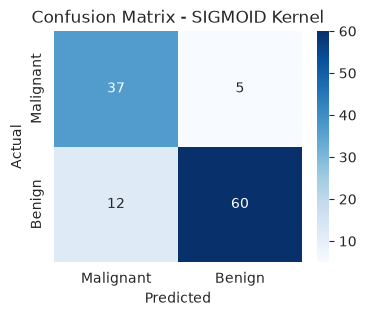

In [25]:
model_sigmoid, acc_sigmoid = train_and_evaluate('sigmoid', gamma='scale')

## 6. Comparing All Kernels

Let's place all accuracies side by side to see which kernel is the winner.

In [26]:
results = pd.DataFrame({
    'Kernel'  : ['Linear', 'Polynomial', 'RBF', 'Sigmoid'],
    'Accuracy': [acc_linear, acc_poly, acc_rbf, acc_sigmoid]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

results

,Kernel,Accuracy
0,Linear,0.982456
1,RBF,0.964912
2,Polynomial,0.885965
3,Sigmoid,0.850877


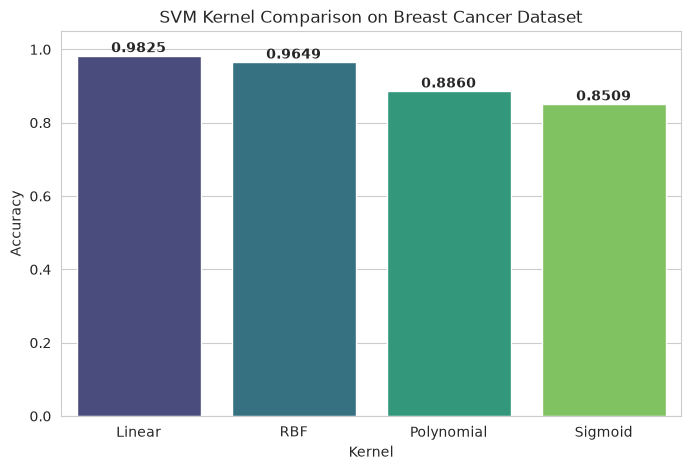

In [27]:
plt.figure(figsize=(8, 5))
bars = sns.barplot(x='Kernel', y='Accuracy', data=results, palette='viridis')
plt.title('SVM Kernel Comparison on Breast Cancer Dataset')
plt.ylim(0, 1.05)

for i, v in enumerate(results['Accuracy']):
    bars.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.show()

## 9. Conclusion

**What we did in this notebook:**

1. Loaded and explored the **Breast Cancer Wisconsin** dataset (569 samples, 30 features).
2. Performed EDA &mdash; checked shape, info, missing values, target distribution and feature correlations.
3. Removed **highly correlated features** (|corr| > 0.90) to fight multicollinearity.
4. **Scaled features** using `StandardScaler` (critical for SVM because it is distance-based).
5. Trained SVM with **all four kernel tricks**:
    - Linear
    - Polynomial (degree=3)
    - RBF (Gaussian)
    - Sigmoid
6. Compared their accuracies side by side with a bar plot.
7. Selected the **best-performing kernel** as the final model and evaluated it on the test set.
8. Built a **prediction function** to use the model on new data.

**Key takeaway:** For the breast cancer dataset, the **linear** and **RBF** kernels usually perform best because the data is roughly linearly separable after standardization. The sigmoid kernel typically lags behind. Always scale your features before training an SVM!